# Figure 1.2.1 — Drift Rate Heatmap: Excitability × Volatility

Sweeps excitability amplitude **E** and synaptic volatility **\u03c3** across a grid.
For each combination the cumulative drift rate

$$\Delta = \sum_{i=2}^{N_{\text{event}}} \bigl(1 - \text{corr}(V_1,\, V_i)\bigr)$$

is computed and averaged over seeds ($V_i$ = population firing-rate vector at end of day $i$).
Bright regions indicate parameter combinations that produce high drift.


In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from model import (ModelParams, get_or_run, extract_arrays,
                   compute_population_vectors, compute_drift_rate,
                   run_grid_sweep, run_tauw_sweep)
from plot_style import apply_style, COLORS, CMAPS, FIG_SIZES, FONT, LW


## Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `E_values` | [0, 0.5, 1.0, 1.5, 2.0] | Excitability amplitudes to sweep |
| `vol_std_values` | [0, 0.01, 0.02, 0.04, 0.06] | Volatility std dev values to sweep |
| `seeds` | [0, 1, 2] | Random seeds (drift averaged across seeds) |


In [2]:
NOTEBOOK_DIR = os.path.abspath("")
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, "saved_figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Sweep parameters ─────────────────────────────────────────────
E_values       = [0.0, 0.5, 1.0, 1.5, 2.0]
vol_std_values = [0.0, 0.01, 0.02, 0.04, 0.06]
seeds          = [0, 1, 2]
base_params    = ModelParams()
DATA_NAME      = "fig1_2_1_sweep"
# ─────────────────────────────────────────────────────────────────────────────
total_sims = len(E_values) * len(vol_std_values) * len(seeds)
print(f"Grid: {len(E_values)} E × {len(vol_std_values)} vol_std × {len(seeds)} seeds = {total_sims} simulations")


Grid: 5 E × 5 vol_std × 3 seeds = 75 simulations


In [3]:
sweep = run_grid_sweep(
    E_values, vol_std_values, seeds,
    base_params=base_params,
    name=DATA_NAME,
)
drift_mean = sweep["drift"].mean(axis=2)   # (nE, nvol)
drift_std  = sweep["drift"].std(axis=2)
print(f"Drift: min={drift_mean.min():.3f}  max={drift_mean.max():.3f}  "
      f"(mean std over seeds: {drift_std.mean():.3f})")


  [75/75] E=2.00  vol_std=0.0600  seed=2
Drift: min=0.005  max=3.161  (mean std over seeds: 0.263)


## Figure 1.2.1

Heatmap of cumulative drift rate Δ across the E × σ parameter space.
Each cell is the mean over seeds; the canonical operating point is marked with a star.


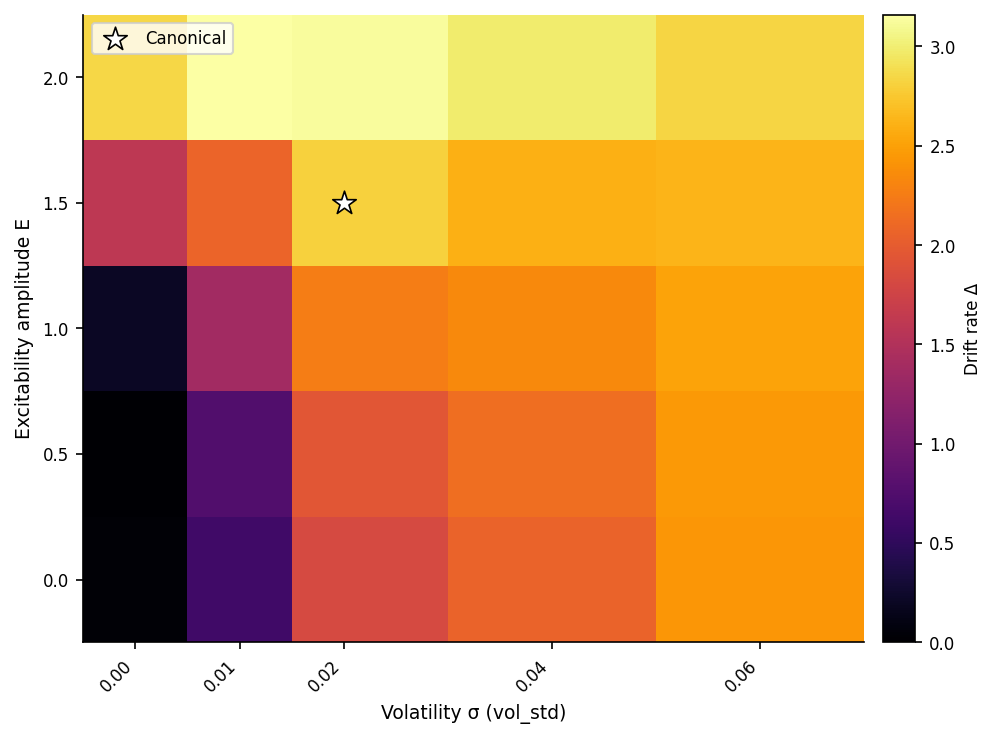

In [4]:
apply_style()

E_arr   = sweep["E_values"]
vol_arr = sweep["vol_std_values"]
X, Y    = np.meshgrid(vol_arr, E_arr)

fig, ax = plt.subplots(figsize=FIG_SIZES["half"])

pcm = ax.pcolormesh(X, Y, drift_mean, cmap=CMAPS["heatmap"], shading="auto", vmin=0)
cb  = plt.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label("Drift rate Δ", fontsize=FONT["colorbar"])

# Mark canonical operating point
ax.scatter([base_params.vol_std], [base_params.E],
           marker="*", s=140, color="white", edgecolors="black", lw=0.8,
           zorder=5, label="Canonical")
ax.legend(fontsize=FONT["annotation"], loc="upper left")

ax.set_xlabel("Volatility σ (vol_std)")
ax.set_ylabel("Excitability amplitude E")

ax.set_xticks(vol_arr)
ax.set_yticks(E_arr)
ax.set_xticklabels([f"{v:.2f}" for v in vol_arr],
                   rotation=45, ha="right", fontsize=FONT["tick"])
ax.set_yticklabels([f"{e:.1f}" for e in E_arr], fontsize=FONT["tick"])

plt.tight_layout()
plt.show()


In [5]:
out_path = os.path.join(FIGURES_DIR, "fig1_2_1_heatmap.pdf")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Figure saved -> {out_path}")


Figure saved -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\saved_figures\fig1_2_1_heatmap.pdf
